Articles with Correct Sentiment Matching EPS Surprise:

Quarter                                                                                                                        Headline                                     Authors Sentiment EPS_Sentiment
Q1 2025                                               Andrew Forrest fires back at ExxonMobil’s claims of ‘smear campaigns and lawfare’                                 Ben Doherty  Negative      Negative
Q1 2025                                                             Hampshire caught up in ‘sportswashing’ T20 row despite green claims                                 Taha Hashim  Negative      Negative
Q1 2025                                   Five firms in plastic pollution alliance ‘made 1,000 times more plastic than they cleaned up’                              Sandra Laville  Negative      Negative
Q1 2025                                                Big oil firms knew of dire effects of fossil fuels as early as 1950s, mem

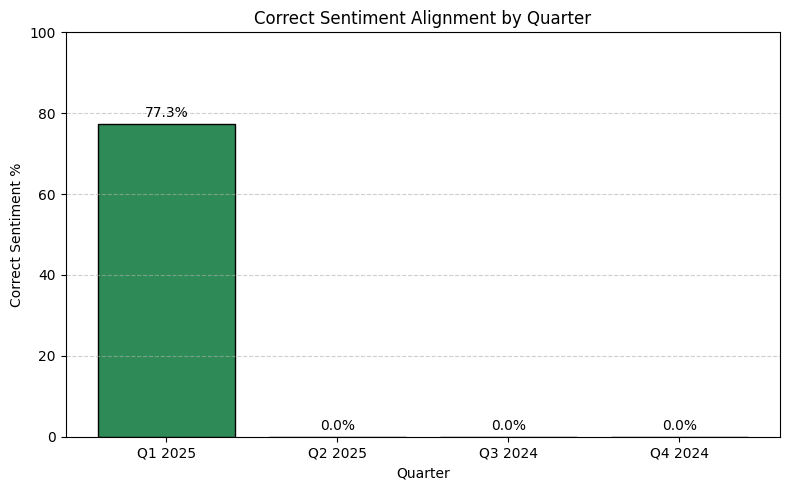

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Load Excel file and read all sheets
file_path = "ExxonMobil_with_sentiment.xlsx"  # Update as needed
xls = pd.ExcelFile(file_path)
sheet_names = xls.sheet_names

# Step 2: Combine sheets into a single DataFrame, labeling by quarter
combined_df = pd.concat(
    [xls.parse(sheet).assign(Quarter=sheet) for sheet in sheet_names],
    ignore_index=True
)

# Step 3: Define true EPS sentiment direction for each quarter
eps_sentiment = {
    'Q2 2025': 'Positive',   # EPS Surprise: 0.57%
    'Q1 2025': 'Negative',   # EPS Surprise: -5.65%
    'Q4 2024': 'Positive',   # EPS Surprise: 2.13%
    'Q3 2024': 'Positive'    # EPS Surprise: 6.47%
}

# Step 4: Tag articles with sentiment alignment
combined_df['Sentiment'] = combined_df['Sentiment'].fillna('Neutral')
combined_df['EPS_Sentiment'] = combined_df['Quarter'].map(eps_sentiment)
combined_df['Sentiment_Alignment'] = combined_df['Sentiment'] == combined_df['EPS_Sentiment']

# Step 5: Filter only correctly aligned articles
correct_df = combined_df[combined_df['Sentiment_Alignment']][
    ['Quarter', 'Headline', 'Authors', 'Sentiment', 'EPS_Sentiment']
]

print("Articles with Correct Sentiment Matching EPS Surprise:\n")
print(correct_df.to_string(index=False))

# Step 6: Compute percentage of correctly aligned sentiment per quarter
correct_sentiment_pct = (
    combined_df.groupby('Quarter')['Sentiment_Alignment']
    .mean()
    .reset_index()
    .rename(columns={'Sentiment_Alignment': 'Correct Sentiment %'})
)
correct_sentiment_pct['Correct Sentiment %'] *= 100

# Step 7: Ensure all quarters in EPS list are present
for q in eps_sentiment:
    if q not in correct_sentiment_pct['Quarter'].values:
        correct_sentiment_pct = pd.concat([
            correct_sentiment_pct,
            pd.DataFrame({'Quarter': [q], 'Correct Sentiment %': [0]})
        ], ignore_index=True)

# Step 8: Sort quarters chronologically
correct_sentiment_pct = correct_sentiment_pct.sort_values(by='Quarter')

# Step 9: Plot chart
plt.figure(figsize=(8, 5))
bars = plt.bar(
    correct_sentiment_pct['Quarter'],
    correct_sentiment_pct['Correct Sentiment %'],
    color='seagreen',
    edgecolor='black'
)

# Annotate bars with %
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center', va='bottom')

plt.title('Correct Sentiment Alignment by Quarter')
plt.xlabel('Quarter')
plt.ylabel('Correct Sentiment %')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()